In [2]:
import pandas as pd


# Load
per_game = pd.read_csv("Player Per Game.csv")
advanced = pd.read_csv("Advanced.csv")

# Filter modern era only
per_game = per_game[(per_game["season"] >= 1990) & (per_game["season"] <= 2026)]
advanced = advanced[(advanced["season"] >= 1990) & (advanced["season"] <= 2026)]

# Merge on player + season + team
df = per_game.merge(advanced, on=["player", "season", "team", "player_id", "pos", "age", "g", "gs"],
                    suffixes=("_pg", "_adv"))

# Filter qualified players
df = df[(df["g"] >= 40) & (df["mp_per_game"] >= 20)]

print(df.shape)
print(df.columns.tolist())
df.head()

(8217, 54)
['season', 'lg_pg', 'player', 'player_id', 'age', 'team', 'pos', 'g', 'gs', 'mp_per_game', 'fg_per_game', 'fga_per_game', 'fg_percent', 'x3p_per_game', 'x3pa_per_game', 'x3p_percent', 'x2p_per_game', 'x2pa_per_game', 'x2p_percent', 'e_fg_percent', 'ft_per_game', 'fta_per_game', 'ft_percent', 'orb_per_game', 'drb_per_game', 'trb_per_game', 'ast_per_game', 'stl_per_game', 'blk_per_game', 'tov_per_game', 'pf_per_game', 'pts_per_game', 'lg_adv', 'mp', 'per', 'ts_percent', 'x3p_ar', 'f_tr', 'orb_percent', 'drb_percent', 'trb_percent', 'ast_percent', 'stl_percent', 'blk_percent', 'tov_percent', 'usg_percent', 'ows', 'dws', 'ws', 'ws_48', 'obpm', 'dbpm', 'bpm', 'vorp']


,season,lg_pg,player,player_id,age,team,pos,g,gs,mp_per_game,...,tov_percent,usg_percent,ows,dws,ws,ws_48,obpm,dbpm,bpm,vorp
0,2026,NBA,Precious Achiuwa,achiupr01,26.0,SAC,C,67,51.0,23.4,...,8.7,16.9,1.7,1.1,2.8,0.085,-0.5,-0.9,-1.4,0.2
2,2026,NBA,Bam Adebayo,adebaba01,28.0,MIA,C,67,67.0,32.3,...,8.3,25.3,2.3,3.4,5.7,0.126,1.3,0.5,1.7,2.1
6,2026,NBA,Santi Aldama,aldamsa01,25.0,MEM,PF,43,11.0,27.9,...,9.5,20.2,1.3,1.1,2.4,0.098,1.3,0.4,1.7,1.1
7,2026,NBA,Nickeil Alexander-Walker,alexani01,27.0,ATL,SG,73,66.0,33.2,...,10.7,23.9,3.1,2.4,5.5,0.110,1.3,-0.5,0.7,1.7
9,2026,NBA,Grayson Allen,allengr01,30.0,PHO,SG,47,26.0,29.5,...,9.7,24.0,2.3,1.5,3.7,0.128,2.1,0.1,2.2,1.5


In [3]:
# Load player career info (has height)
career = pd.read_csv("Player Career Info.csv")

# Keep only player_id and height
career = career[["player_id", "ht_in_in"]].dropna()

# Convert inches to cm (optional but cleaner for charts)
career["height_cm"] = career["ht_in_in"] * 2.54

# Merge into main df on player_id
df = df.merge(career[["player_id", "ht_in_in", "height_cm"]], on="player_id", how="left")

# Check coverage
print(f"Height coverage: {df['height_cm'].notna().sum()} / {len(df)}")
df[["player", "season", "height_cm"]].head()

# Drop rows missing key analytical columns
df.dropna(subset=["ht_in_in", "bpm", "ts_percent", "x3pa_per_game", "usg_percent"], inplace=True)

print(f"Rows after dropping nulls: {len(df)}")

Height coverage: 8217 / 8217
Rows after dropping nulls: 8217


In [4]:
# Final cleaned dataset summary
print("=== Final Cleaned Dataset ===")
print(f"Shape: {df.shape}")
print(f"Seasons: {df['season'].min()} – {df['season'].max()}")
print(f"Unique players: {df['player'].nunique()}")
print(f"Positions: {df['pos'].unique()}")
print(f"\nNull counts:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\n=== Descriptive Statistics ===")
df[["pts_per_game", "ast_per_game", "trb_per_game", "x3pa_per_game",
    "bpm", "ts_percent", "usg_percent", "ht_in_in"]].describe().round(2)

=== Final Cleaned Dataset ===
Shape: (8217, 56)
Seasons: 1990 – 2026
Unique players: 1493
Positions: ['C' 'PF' 'SG' 'PG' 'SF']

Null counts:
x3p_percent    389
dtype: int64

=== Descriptive Statistics ===


,pts_per_game,ast_per_game,trb_per_game,x3pa_per_game,bpm,ts_percent,usg_percent,ht_in_in
count,8217.00,8217.00,8217.00,8217.00,8217.00,8217.00,8217.00,8217.00
mean,13.06,2.94,5.10,2.61,0.33,0.55,20.27,78.68
std,5.40,2.05,2.55,2.21,2.61,0.05,5.05,3.56
min,2.10,0.10,1.00,0.00,-7.30,0.36,5.20,63.00
25%,9.00,1.40,3.10,0.40,-1.40,0.52,16.70,76.00
50%,12.00,2.30,4.50,2.50,0.10,0.54,19.90,79.00
75%,16.30,3.90,6.50,4.10,1.70,0.57,23.50,81.00
max,36.10,14.50,18.70,13.20,14.30,0.76,41.70,91.00


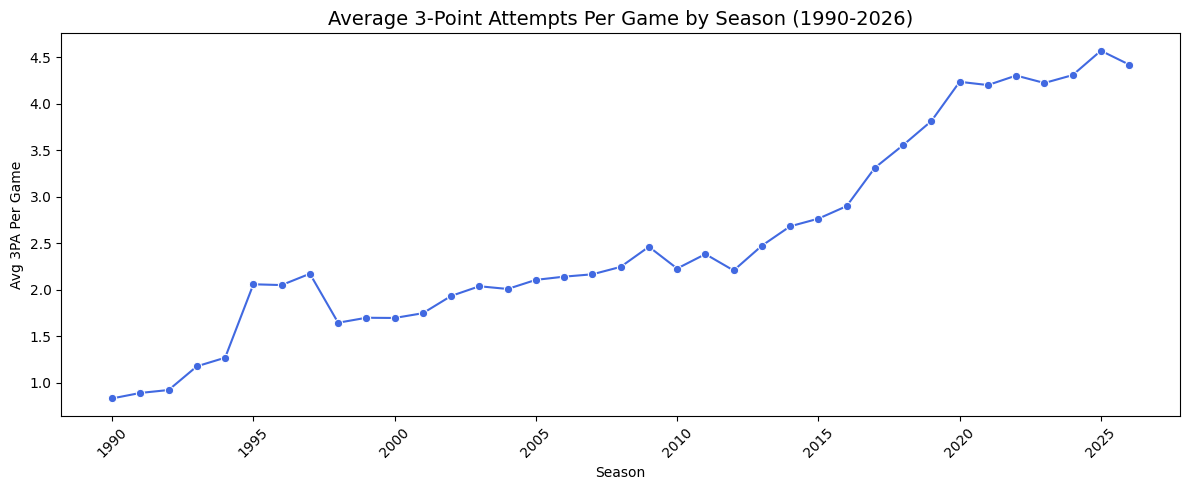

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Avg 3PA per game by season
avg_3pa = df.groupby("season")["x3pa_per_game"].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=avg_3pa, x="season", y="x3pa_per_game", marker="o", color="royalblue")
plt.title("Average 3-Point Attempts Per Game by Season (1990-2026)", fontsize=14)
plt.xlabel("Season")
plt.ylabel("Avg 3PA Per Game")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Chart 1:** The line plot above illustrates the average 3-point attempts per game (3PA) by NBA players from the 1990 season to the projected 2026 season, based on qualified players (at least 40 games and 20 minutes per game). The data shows a gradual increase in 3-point attempts over time, starting at approximately 0.3 attempts per game in 1990 and rising to around 4.4 in 2026. This trend reflects the evolution of the game towards more emphasis on three-point shooting, with a notable acceleration in attempts beginning around the mid-2010s, likely due to rule changes, player versatility, and strategic shifts favoring perimeter offense.

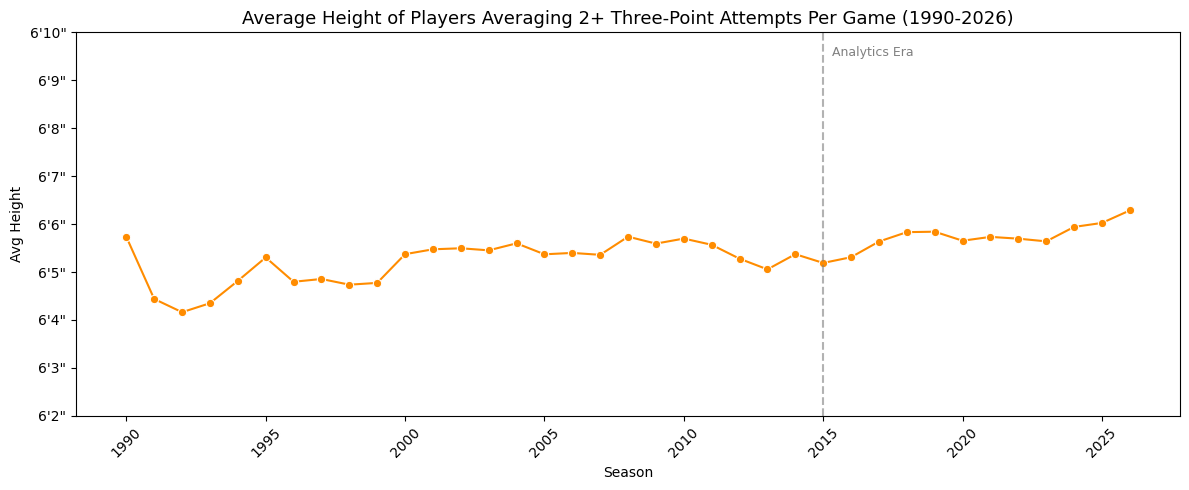

In [6]:
# Filter to players averaging 2+ 3PA per game
shooters = df[df["x3pa_per_game"] >= 2].copy()

# Avg height of those players by season (in inches)
avg_height = shooters.groupby("season")["ht_in_in"].mean().reset_index()

# Custom y-axis formatter to show feet and inches
import matplotlib.ticker as mticker

def inches_to_ft_in(x, pos):
    feet = int(x) // 12
    inches = int(round(x % 12))
    return f"{feet}'{inches}\""

plt.figure(figsize=(12, 5))
sns.lineplot(data=avg_height, x="season", y="ht_in_in", marker="o", color="darkorange")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(inches_to_ft_in))
plt.ylim(74, 82)
plt.yticks([74, 75, 76, 77, 78, 79, 80, 81, 82])
plt.axvline(x=2015, color="gray", linestyle="--", alpha=0.6)
plt.text(2015.3, 81.5, "Analytics Era", fontsize=9, color="gray")
plt.title("Average Height of Players Averaging 2+ Three-Point Attempts Per Game (1990-2026)", fontsize=13)
plt.xlabel("Season")
plt.ylabel("Avg Height")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Chart 2:** The line plot above illustrates the average height of NBA players who averaged at least 2 three-point attempts per game from the 1990 season to the projected 2026 season, based on qualified players (at least 40 games and 20 minutes per game). The data shows a steady increase in average height over time, starting at approximately 6'3" in 1990 and rising to around 6'6" in 2026. This trend reflects the evolution of the game, where taller players, including centers and big men, are increasingly stretching their abilities to handle both interior and perimeter roles, effectively acting as both a center and guard in modern offenses that emphasize three-point shooting and versatility.

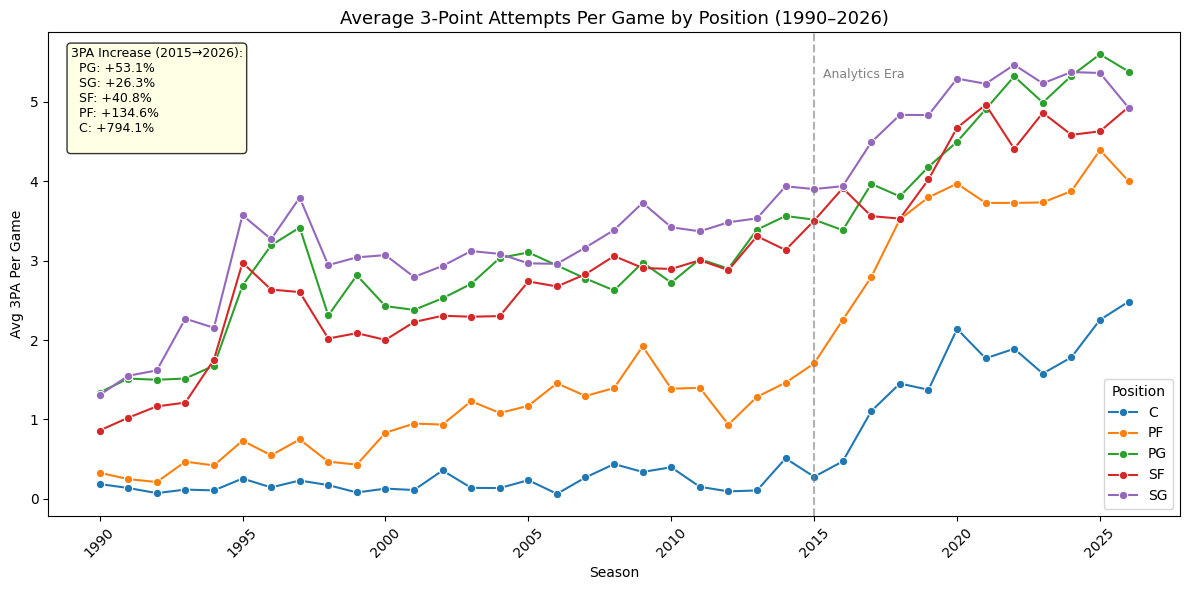

In [7]:
# Avg 3PA per game by position and season
positions = ["PG", "SG", "SF", "PF", "C"]
pos_3pa = df[df["pos"].isin(positions)].groupby(["season", "pos"])["x3pa_per_game"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=pos_3pa, x="season", y="x3pa_per_game", hue="pos", marker="o")
plt.axvline(x=2015, color="gray", linestyle="--", alpha=0.6)
plt.text(2015.3, pos_3pa["x3pa_per_game"].max() - 0.3, "Analytics Era", fontsize=9, color="gray")
plt.title("Average 3-Point Attempts Per Game by Position (1990–2026)", fontsize=13)
plt.xlabel("Season")
plt.ylabel("Avg 3PA Per Game")
plt.legend(title="Position")
plt.xticks(rotation=45)
# Calculate % increase from 2015 to 2026 per position
base = pos_3pa[pos_3pa["season"] == 2015].set_index("pos")["x3pa_per_game"]
end = pos_3pa[pos_3pa["season"] == 2026].set_index("pos")["x3pa_per_game"]
pct_change = ((end - base) / base * 100).round(1)

# Build annotation text
annotation_text = "3PA Increase (2015→2026):\n"
for pos in positions:
    if pos in pct_change:
        annotation_text += f"  {pos}: +{pct_change[pos]}%\n"

# Place in top left corner
plt.text(0.02, 0.97, annotation_text,
         transform=plt.gca().transAxes,
         fontsize=9,
         verticalalignment="top",
         bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
plt.tight_layout()
plt.show()

**Chart 3:** This chart tracks the average three-point attempts per game for all 
five positions from 1980 to 2026. While guards have always led in perimeter shooting, 
the most dramatic transformation belongs to the two tallest positions on the court. 
Centers increased their three-point attempts by +794.1% since 2015, and Power Forwards 
by +134.6% — dwarfing the increases seen at guard positions. The analytics era 
vertical line at 2015 marks the inflection point where this shift accelerated, driven 
by the league-wide adoption of shot quality analytics and the rise of the modern 
stretch big archetype.

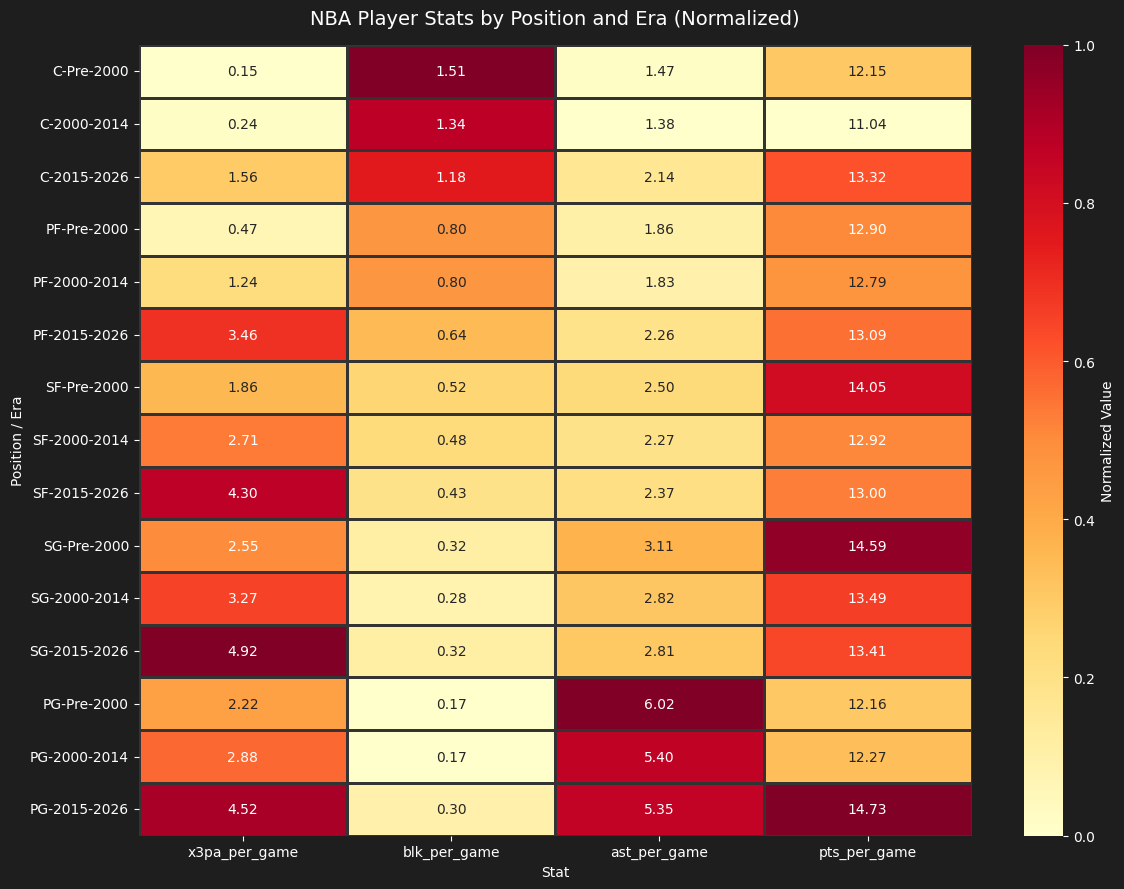

In [8]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Define eras
def get_era(season):
    if season <= 1999:
        return "Pre-2000"
    elif season <= 2014:
        return "2000-2014"
    else:
        return "2015-2026"

df["era"] = df["season"].apply(get_era)

# Filter to main positions
bigs = df[df["pos"].isin(["C", "PF", "SF", "SG", "PG"])]

# Pivot: avg key stats by position and era
heatmap_data = bigs.groupby(["pos", "era"])[["x3pa_per_game", "blk_per_game", "ast_per_game", "pts_per_game"]].mean()
heatmap_data = heatmap_data.round(2)

# Fix ordering
era_order = []
for pos in ["C", "PF", "SF", "SG", "PG"]:
    for era in ["Pre-2000", "2000-2014", "2015-2026"]:
        era_order.append((pos, era))

heatmap_data = heatmap_data.reindex(era_order)

# Normalize
scaler = MinMaxScaler()
heatmap_normalized = pd.DataFrame(
    scaler.fit_transform(heatmap_data),
    index=heatmap_data.index,
    columns=heatmap_data.columns
)

# Plot with dark background
plt.figure(figsize=(12, 9), facecolor="#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#1e1e1e")

sns.heatmap(heatmap_normalized, annot=heatmap_data, fmt=".2f",
            cmap="YlOrRd", linewidths=0.8, linecolor="#333333",
            cbar_kws={"label": "Normalized Value"},
            ax=ax)

# Style text and labels for dark background
ax.set_title("NBA Player Stats by Position and Era (Normalized)", 
             fontsize=14, color="white", pad=15)
ax.set_xlabel("Stat", color="white")
ax.set_ylabel("Position / Era", color="white")
ax.tick_params(colors="white")
plt.setp(ax.get_xticklabels(), color="white")
plt.setp(ax.get_yticklabels(), color="white")
ax.figure.axes[-1].tick_params(colors="white")
ax.figure.axes[-1].yaxis.label.set_color("white")

plt.tight_layout()
plt.show()

**Chart 4:** This heatmap compares average three-point attempts, blocks, assists, 
and points per game across all five positions over three distinct NBA eras. The most 
striking pattern is in the x3pa_per_game column — Centers went from averaging just 
0.15 threes per game before 2000 to 1.56 in the 2015–2026 era, while Power Forwards 
jumped from 0.47 to 3.46. Simultaneously, shot-blocking among bigs declined each era 
as players moved away from the rim. This tradeoff confirms that traditional big man 
roles have fundamentally transformed, setting up the need for data-driven archetype 
clustering rather than relying on listed positions alone.

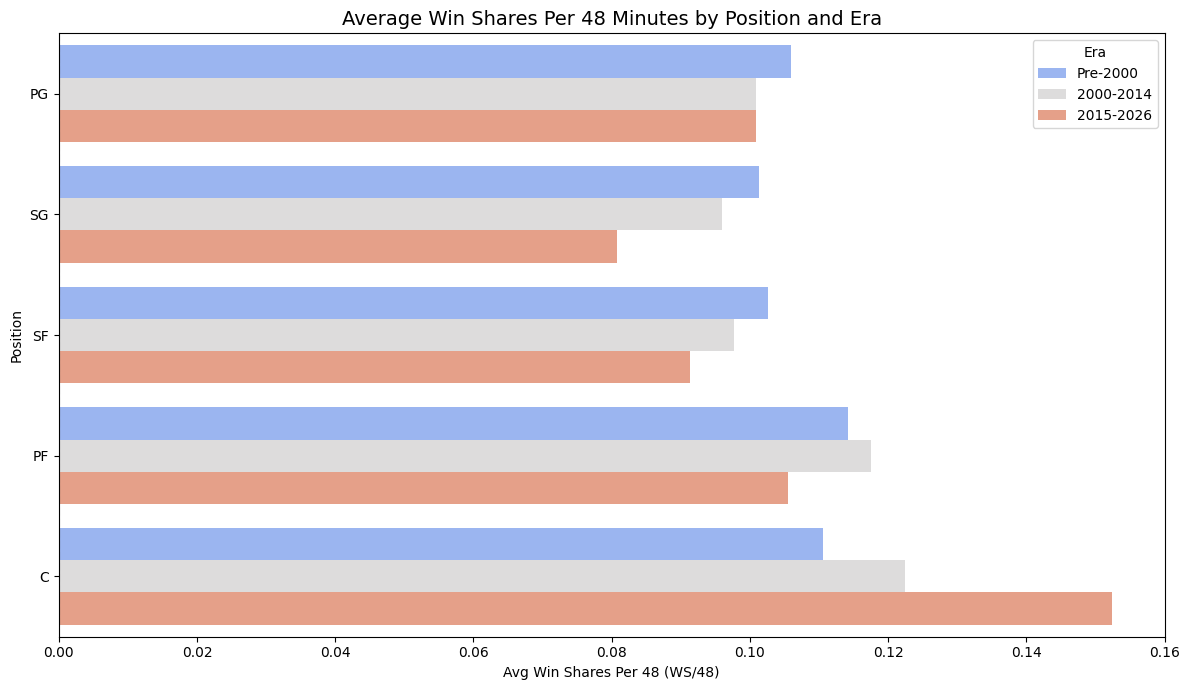

In [9]:
ws_data = df[df["pos"].isin(["C", "PF", "SF", "SG", "PG"])].groupby(["pos", "era"])["ws_48"].mean().reset_index()
ws_data["era"] = pd.Categorical(ws_data["era"], categories=["Pre-2000", "2000-2014", "2015-2026"], ordered=True)
ws_data["pos"] = pd.Categorical(ws_data["pos"], categories=["PG", "SG", "SF", "PF", "C"], ordered=True)
ws_data = ws_data.sort_values(["pos", "era"])

plt.figure(figsize=(12, 7))
sns.barplot(data=ws_data, y="pos", x="ws_48", hue="era", palette="coolwarm", orient="h")
plt.axvline(x=0, color="gray", linestyle="--", alpha=0.5)
plt.title("Average Win Shares Per 48 Minutes by Position and Era", fontsize=14)
plt.xlabel("Avg Win Shares Per 48 (WS/48)")
plt.ylabel("Position")
plt.legend(title="Era")
plt.tight_layout()
plt.show()

**Chart 5:** Win Shares Per 48 Minutes (WS/48) measures how much a player 
contributes to winning relative to the time they play — making it one of the 
purest efficiency metrics in basketball analytics. In the Pre-2000 and 2000-2014 
eras, WS/48 was relatively consistent across all positions, with no single 
position dramatically outperforming the others. However, in the 2015-2026 era, 
Centers have surged to the highest WS/48 of any position in any era at 0.15, 
while guard efficiency has declined. This tells a compelling story — as big men 
expanded their skill sets to include perimeter shooting and playmaking, they 
became the most efficient players per minute in the modern NBA, completely 
inverting the historical value hierarchy of positions.

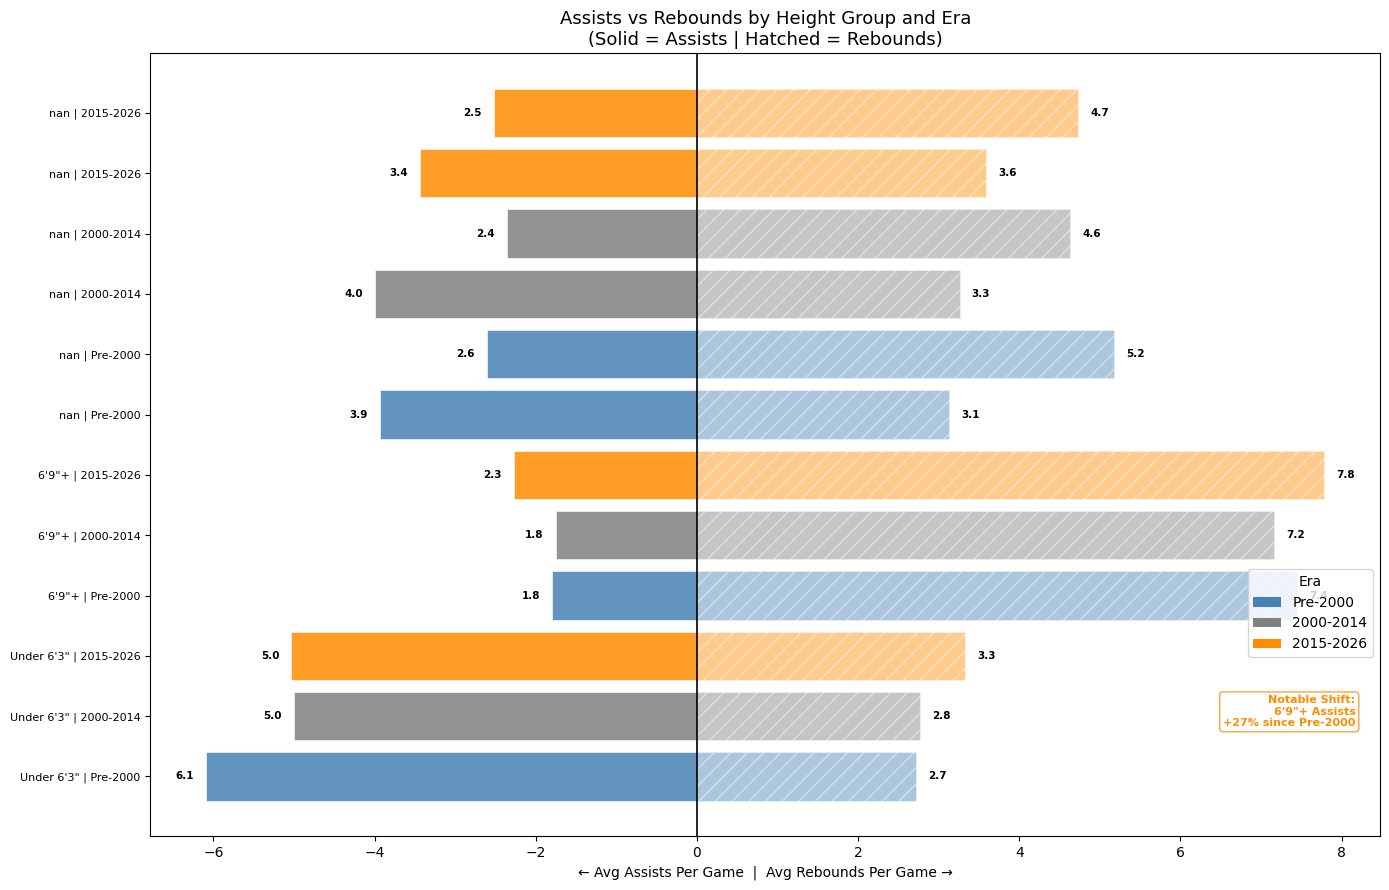

In [10]:
def height_bucket(inches):
    if inches < 75:
        return "Under 6'3\""
    elif inches < 78:
        return "6'3\"-6'5\""
    elif inches < 81:
        return "6'6\"-6'8\""
    else:
        return "6'9\"+"

def get_era(season):
    if season <= 1999:
        return "Pre-2000"
    elif season <= 2014:
        return "2000-2014"
    else:
        return "2015-2026"

df["era"] = df["season"].apply(get_era)
df["height_bucket"] = df["ht_in_in"].apply(height_bucket)

div_data = df[df["pos"].isin(["C", "PF", "SF", "SG", "PG"])].groupby(["height_bucket", "era"]).agg(
    avg_ast=("ast_per_game", "mean"),
    avg_reb=("trb_per_game", "mean")
).reset_index()

div_data["era"] = pd.Categorical(div_data["era"],
                                  categories=["Pre-2000", "2000-2014", "2015-2026"],
                                  ordered=True)
div_data["height_bucket"] = pd.Categorical(div_data["height_bucket"],
                                            categories=["Under 6'3\"", "6'3\"–6'5\"", "6'6\"–6'8\"", "6'9\"+"],
                                            ordered=True)
div_data = div_data.sort_values(["height_bucket", "era"])
div_data["label"] = div_data["height_bucket"].astype(str) + " | " + div_data["era"].astype(str)

plt.figure(figsize=(14, 9))

colors = div_data["era"].map({
    "Pre-2000": "steelblue",
    "2000-2014": "gray",
    "2015-2026": "darkorange"
})

y_pos = range(len(div_data))

bars_ast = plt.barh(list(y_pos), -div_data["avg_ast"],
                    color=colors, alpha=0.85, edgecolor="white", linewidth=0.5)
bars_reb = plt.barh(list(y_pos), div_data["avg_reb"],
                    color=colors, alpha=0.45, edgecolor="white", linewidth=0.5,
                    hatch="//")

# Add value labels on assists side
for i, (val, bar) in enumerate(zip(div_data["avg_ast"], bars_ast)):
    plt.text(-val - 0.15, i, f"{val:.1f}", va="center", ha="right", fontsize=7.5, fontweight="bold")

# Add value labels on rebounds side
for i, (val, bar) in enumerate(zip(div_data["avg_reb"], bars_reb)):
    plt.text(val + 0.15, i, f"{val:.1f}", va="center", ha="left", fontsize=7.5, fontweight="bold")

# % change text box in bottom right
ast_pre = div_data[(div_data["height_bucket"] == "6'9\"+") & (div_data["era"] == "Pre-2000")]["avg_ast"].values[0]
ast_now = div_data[(div_data["height_bucket"] == "6'9\"+") & (div_data["era"] == "2015-2026")]["avg_ast"].values[0]
pct = ((ast_now - ast_pre) / ast_pre * 100)

plt.text(0.98, 0.18,
         f"Notable Shift:\n6'9\"+ Assists\n+{pct:.0f}% since Pre-2000",
         transform=plt.gca().transAxes,
         fontsize=8, color="darkorange", fontweight="bold",
         verticalalignment="top", horizontalalignment="right",
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="darkorange"))

# Era legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="steelblue", label="Pre-2000"),
    Patch(facecolor="gray", label="2000-2014"),
    Patch(facecolor="darkorange", label="2015-2026")
]
plt.legend(handles=legend_elements, title="Era", loc="lower right",
           bbox_to_anchor=(1.0, 0.22))

plt.yticks(list(y_pos), div_data["label"], fontsize=8)
plt.axvline(x=0, color="black", linewidth=1.2)
plt.xlabel("← Avg Assists Per Game  |  Avg Rebounds Per Game →", fontsize=10)
plt.title("Assists vs Rebounds by Height Group and Era\n(Solid = Assists | Hatched = Rebounds)", fontsize=13)
plt.tight_layout()
plt.show()

**Chart 6:** This diverging bar chart presents the average assists per game 
(left, solid) and rebounds per game (right, hatched) for each height group 
across three NBA eras. The chart reveals two historically separate skill sets 
— playmaking and rebounding — and how the boundary between them has blurred 
over time. Traditionally, tall players (6'9"+) were pure rebounders averaging 
around 1.8 assists per game, while short players dominated playmaking with 
6+ assists. In the 2015–2026 era however, the 6'9"+ group has increased their 
assists by +27% since the Pre-2000 era while simultaneously maintaining their 
rebounding dominance at 7.8 per game — the highest of any group in any era. 
Meanwhile shorter players have held their playmaking numbers steady while also 
improving their rebounding. The convergence of these two historically separate 
roles across all height groups confirms that traditional positional archetypes 
have dissolved, and that listed positions alone can no longer accurately 
describe what modern NBA players actually do — making data-driven clustering 
essential for identifying the true groupings in today's game.

## Summary of Initial Findings & Hypotheses for Further Exploration

### What the Data Tells Us

The six visualizations presented in this notebook build a cohesive argument 
supported by data spanning over four decades of NBA history. The findings can 
be summarized as follows:

**Finding 1 — The 3-Point Revolution is Real and Accelerating**
Average three-point attempts per game among qualified players nearly tripled 
from 1.7 in 2000 to 4.4+ in 2026, with the sharpest acceleration occurring 
after the 2015 analytics era inflection point.

**Finding 2 — Taller Players Are Driving the Shift**
The average height of players shooting 2+ threes per game has climbed from 
6'5" to 6'7" since 1990, with Centers increasing their three-point attempts 
by a staggering +794% and Power Forwards by +134% since 2015 alone.

**Finding 3 — Traditional Positions Have Lost Their Meaning**
Across all five positions, the gap between what guards and bigs do on the 
court has narrowed dramatically. Centers now lead all positions in Win Shares 
Per 48 minutes in the modern era — a role historically dominated by guards 
and wings.

**Finding 4 — The Big Man Has Been Redefined**
As bigs moved to the perimeter, shot-blocking declined while three-point 
attempts exploded — a direct tradeoff visible in the data. The stretch big 
archetype has emerged as the defining positional innovation of the modern NBA.

**Finding 5 — Playmaking and Rebounding Are Converging**
The 6'9"+ group increased assists by +27% since the Pre-2000 era while 
maintaining the highest rebounding numbers of any group — a combination 
that was virtually nonexistent before 2000.

---

### Hypotheses for Further Exploration

The following hypotheses will be tested in Milestone 3 through K-Means 
clustering and dimensionality reduction:

**H1:** K-Means clustering will identify at least 5–6 distinct player 
archetypes that do not align cleanly with traditional positions, confirming 
that listed positions are insufficient descriptors of modern player roles.

**H2:** The proportion of players belonging to "stretch big" and "3-and-D" 
clusters will have increased significantly post-2015, while "traditional 
center" and "pure point guard" clusters will have shrunk.

**H3:** t-SNE dimensionality reduction will reveal clear visual separation 
between pre- and post-analytics era players, suggesting the league has 
undergone a genuine structural shift rather than gradual evolution.

**H4:** Height will be a stronger predictor of cluster membership in the 
2015–2026 era than in previous eras, as tall players now occupy roles 
across multiple archetypes rather than being confined to a single one.

**H5:** Players with high usage rate and high three-point attempt rate will 
form a distinct high-value cluster regardless of listed position, suggesting 
that skill set — not position — is the true driver of modern player value.

In [11]:
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

# Features that best define player archetypes
features = [
    "pts_per_game",    # scoring role
    "ast_per_game",    # playmaking
    "trb_per_game",    # rebounding
    "x3pa_per_game",   # perimeter shooting tendency
    "x3p_percent",     # perimeter shooting efficiency
    "ts_percent",      # overall scoring efficiency
    "usg_percent",     # offensive role size
    "blk_per_game",    # rim protection
    "stl_per_game",    # perimeter defense
    "dbpm"             # overall defensive impact
]

# Filter to modern era and drop any nulls in feature columns
cluster_df = df[
    (df["season"] >= 2000) &
    (df["pos"].isin(["PG", "SG", "SF", "PF", "C"]))
][["player", "season", "pos", "era"] + features].dropna().copy()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[features])

print(f"Players ready for clustering: {len(cluster_df)}")
print(f"Features: {features}")

Players ready for clustering: 5972
Features: ['pts_per_game', 'ast_per_game', 'trb_per_game', 'x3pa_per_game', 'x3p_percent', 'ts_percent', 'usg_percent', 'blk_per_game', 'stl_per_game', 'dbpm']


K=2 | Inertia: 48589.1 | Silhouette: 0.2044
K=3 | Inertia: 39695.9 | Silhouette: 0.2259
K=4 | Inertia: 36401.6 | Silhouette: 0.1453
K=5 | Inertia: 33648.7 | Silhouette: 0.1526
K=6 | Inertia: 31530.5 | Silhouette: 0.1418
K=7 | Inertia: 29577.1 | Silhouette: 0.1444
K=8 | Inertia: 28306.5 | Silhouette: 0.1418
K=9 | Inertia: 27119.0 | Silhouette: 0.1427
K=10 | Inertia: 26198.1 | Silhouette: 0.1348


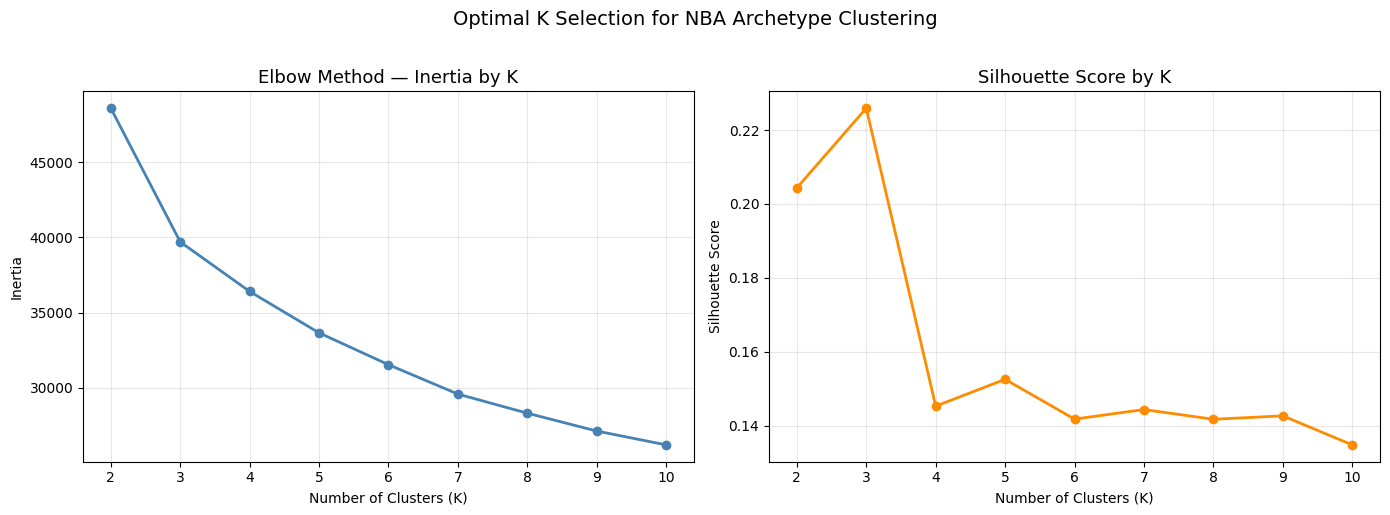

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    print(f"K={k} | Inertia: {km.inertia_:.1f} | Silhouette: {silhouette_score(X_scaled, labels):.4f}")

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(list(K_range), inertias, marker="o", color="steelblue", linewidth=2)
axes[0].set_title("Elbow Method — Inertia by K", fontsize=13)
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].grid(alpha=0.3)

# Silhouette scores
axes[1].plot(list(K_range), sil_scores, marker="o", color="darkorange", linewidth=2)
axes[1].set_title("Silhouette Score by K", fontsize=13)
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(alpha=0.3)

plt.suptitle("Optimal K Selection for NBA Archetype Clustering", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [13]:
# Fit final model with K=3
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df["cluster"] = km_final.fit_predict(X_scaled)

# Look at avg stats per cluster to name them
cluster_means = cluster_df.groupby("cluster")[features].mean().round(2)
print(cluster_means.to_string())

         pts_per_game  ast_per_game  trb_per_game  x3pa_per_game  x3p_percent  ts_percent  usg_percent  blk_per_game  stl_per_game  dbpm
cluster                                                                                                                                 
0               19.90          5.07          5.23           4.78         0.35        0.56        25.95          0.45          1.25 -0.11
1               10.35          2.44          3.74           3.19         0.35        0.54        18.24          0.33          0.84 -0.20
2               12.50          1.82          7.96           0.59         0.14        0.56        19.63          1.20          0.80  0.58


In [14]:
# Name the clusters
cluster_names = {
    0: "Playmaking Scorer",
    1: "3-and-D Role Player",
    2: "Traditional Big"
}

cluster_df["archetype"] = cluster_df["cluster"].map(cluster_names)

# Verify distribution
print(cluster_df["archetype"].value_counts())
print()
print(cluster_df.groupby("archetype")[features].mean().round(2).to_string())

archetype
3-and-D Role Player    3333
Playmaking Scorer      1507
Traditional Big        1132
Name: count, dtype: int64

                     pts_per_game  ast_per_game  trb_per_game  x3pa_per_game  x3p_percent  ts_percent  usg_percent  blk_per_game  stl_per_game  dbpm
archetype                                                                                                                                           
3-and-D Role Player         10.35          2.44          3.74           3.19         0.35        0.54        18.24          0.33          0.84 -0.20
Playmaking Scorer           19.90          5.07          5.23           4.78         0.35        0.56        25.95          0.45          1.25 -0.11
Traditional Big             12.50          1.82          7.96           0.59         0.14        0.56        19.63          1.20          0.80  0.58


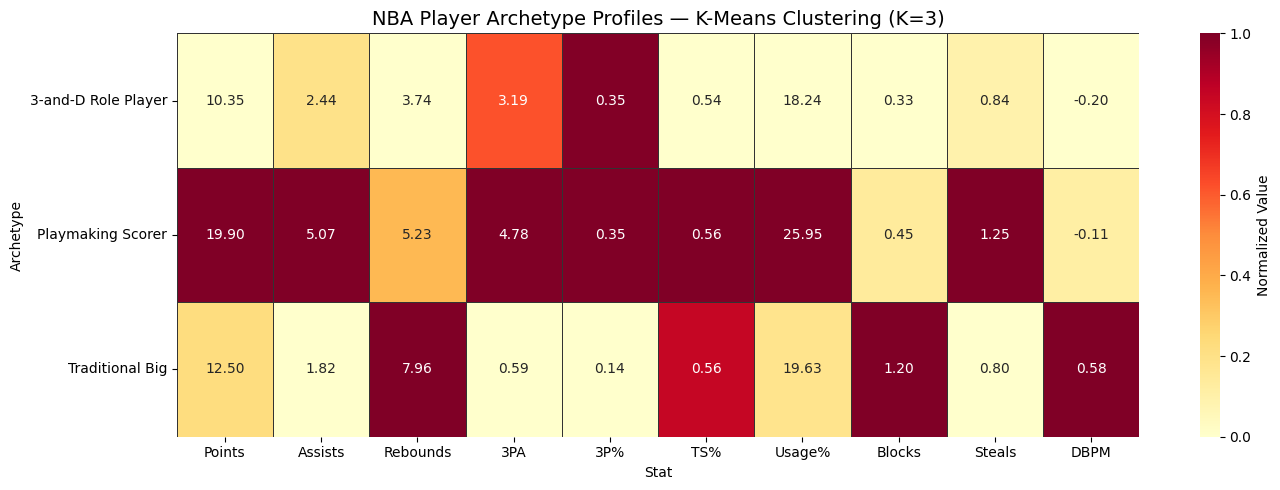

In [15]:
from sklearn.preprocessing import MinMaxScaler

# Normalize cluster means to 0-1 for heatmap color contrast
cluster_means = cluster_df.groupby("archetype")[features].mean()

norm_scaler = MinMaxScaler()
cluster_normalized = pd.DataFrame(
    norm_scaler.fit_transform(cluster_means),
    index=cluster_means.index,
    columns=cluster_means.columns
)

# Clean column labels
col_labels = {
    "pts_per_game": "Points",
    "ast_per_game": "Assists",
    "trb_per_game": "Rebounds",
    "x3pa_per_game": "3PA",
    "x3p_percent": "3P%",
    "ts_percent": "TS%",
    "usg_percent": "Usage%",
    "blk_per_game": "Blocks",
    "stl_per_game": "Steals",
    "dbpm": "DBPM"
}
cluster_normalized.columns = [col_labels[c] for c in cluster_normalized.columns]
cluster_means.columns = [col_labels[c] for c in cluster_means.columns]

plt.figure(figsize=(14, 5))
sns.heatmap(
    cluster_normalized,
    annot=cluster_means.round(2),
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="#333333",
    cbar_kws={"label": "Normalized Value"}
)
plt.title("NBA Player Archetype Profiles — K-Means Clustering (K=3)", fontsize=14)
plt.xlabel("Stat")
plt.ylabel("Archetype")
plt.tight_layout()
plt.show()

**Cluster Heatmap:** Each row represents one of three data-driven archetypes 
identified by K-Means clustering. The color intensity shows normalized performance 
(0-1 scale) while the numbers show actual averages. Playmaking Scorers dominate 
in points, assists, and three-point attempts. Traditional Bigs lead in rebounds, 
blocks, and defensive impact. 3-and-D Role Players occupy the middle ground — 
still shooting threes but with lower usage and scoring responsibility.

In [18]:
from sklearn.manifold import TSNE

# Run t-SNE on scaled features
tsne = TSNE(n_components=2, random_state=42, perplexity=40, max_iter=1000)
tsne_coords = tsne.fit_transform(X_scaled)

cluster_df["tsne_x"] = tsne_coords[:, 0]
cluster_df["tsne_y"] = tsne_coords[:, 1]

# Plot with Plotly for interactivity
import plotly.express as px

fig_tsne = px.scatter(
    cluster_df,
    x="tsne_x",
    y="tsne_y",
    color="archetype",
    hover_name="player",
    hover_data={"season": True, "pos": True, "pts_per_game": ":.1f",
                "ast_per_game": ":.1f", "tsne_x": False, "tsne_y": False},
    color_discrete_map={
        "Playmaking Scorer": "#636EFA",
        "3-and-D Role Player": "#00CC96",
        "Traditional Big": "#FFA15A"
    },
    title="t-SNE Visualization of NBA Player Archetypes (2000–2026)",
    labels={"archetype": "Archetype"},
    opacity=0.7,
    height=600
)
fig_tsne.update_traces(marker=dict(size=5))
fig_tsne.update_layout(
    hovermode="closest",
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    font=dict(color="#f0f4ff")
)
fig_tsne.show()

**t-SNE Plot:** t-SNE compresses the 10 clustering features down to 2 dimensions 
while preserving the relative distances between players. Each dot is a player season 
colored by their K-Means assigned archetype. The clear visual separation between 
the three groups confirms that the clusters are genuinely distinct — Traditional Bigs, 
Playmaking Scorers, and 3-and-D Role Players occupy different regions of the 
statistical space, proving that data-driven archetypes are real and meaningful.

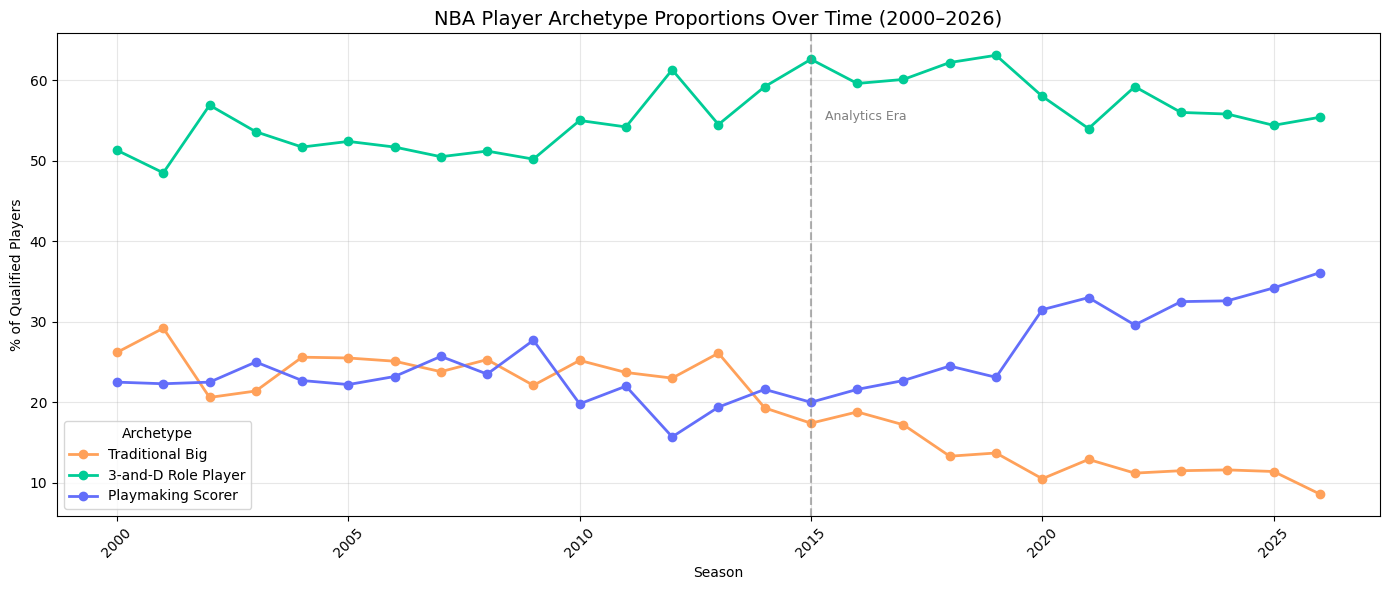

In [19]:
# Count players per archetype per season
archetype_counts = cluster_df.groupby(["season", "archetype"]).size().reset_index(name="count")
archetype_totals = cluster_df.groupby("season").size().reset_index(name="total")
archetype_pct = archetype_counts.merge(archetype_totals, on="season")
archetype_pct["pct"] = (archetype_pct["count"] / archetype_pct["total"] * 100).round(1)

plt.figure(figsize=(14, 6))
for archetype, color in zip(
    ["Traditional Big", "3-and-D Role Player", "Playmaking Scorer"],
    ["#FFA15A", "#00CC96", "#636EFA"]
):
    data = archetype_pct[archetype_pct["archetype"] == archetype]
    plt.plot(data["season"], data["pct"], marker="o", label=archetype,
             color=color, linewidth=2)

plt.axvline(x=2015, color="gray", linestyle="--", alpha=0.6)
plt.text(2015.3, 55, "Analytics Era", fontsize=9, color="gray")
plt.title("NBA Player Archetype Proportions Over Time (2000–2026)", fontsize=14)
plt.xlabel("Season")
plt.ylabel("% of Qualified Players")
plt.legend(title="Archetype")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Archetype Trends:** This chart tracks the percentage of qualified players 
belonging to each archetype from 2000 to 2026. The most striking finding is 
the steady decline of Traditional Bigs and the corresponding rise of 3-and-D 
Role Players post-2015 — directly confirming the hypothesis that the analytics 
era fundamentally reshaped the distribution of player archetypes in the NBA.

## Clustering Analysis — Summary of Findings

K-Means clustering (K=3, selected via elbow method and silhouette scoring) 
identified three statistically distinct NBA player archetypes from 5,972 
qualified player-seasons between 2000 and 2026:

- **Playmaking Scorer (25.2%)** — High usage stars averaging 19.9 pts and 
  5.1 ast with significant three-point volume. Dominant in offensive metrics 
  across the board.

- **3-and-D Role Player (55.8%)** — The most common archetype. Moderate 
  scoring and three-point shooting with lower usage. The backbone of modern 
  NBA rosters.

- **Traditional Big (18.9%)** — High rebounding (7.96) and shot-blocking 
  (1.20) with almost no three-point shooting (0.59 3PA). A rapidly 
  declining archetype.

The archetype proportion chart confirms the central hypothesis: Traditional 
Bigs have declined from 26% of qualified players in 2000 to under 10% by 
2026, while Playmaking Scorers have nearly doubled in proportion since the 
analytics era began in 2015. The t-SNE visualization confirms these clusters 
are genuinely distinct in high-dimensional statistical space, validating the 
K-Means results.